# Инференс TrOCR (EN + RU)

Грузит лучший чекпойнт (`best/`), распознаёт строку. Задай `BEST_DIR` на свой `outputs/.../best`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import torch
from PIL import Image
from IPython.display import display
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

# BEST_DIR = str(ROOT / 'outputs' / 'trocr_small_bi_pretrain' / 'best')
# BEST_DIR = str(ROOT / 'outputs' / 'trocr_small_bi_pretrain_stage2' / 'best')
BEST_DIR = str(ROOT / 'outputs' / 'trocr_small_bi_finetune' / 'best')
# DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE = 'cpu'
 
model = VisionEncoderDecoderModel.from_pretrained(BEST_DIR).to(DEVICE).eval()
processor = TrOCRProcessor.from_pretrained(BEST_DIR)
print('loaded:', BEST_DIR, '| device:', DEVICE)

Config of the encoder: <class 'transformers.models.deit.modeling_deit.DeiTModel'> is overwritten by shared encoder config: DeiTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "model_type": "deit",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.47.1"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 384,
  "d_model": 256,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 1024,
  "decode

loaded: /workspace/HDD/handwriting-recognition/recognition/outputs/trocr_small_bi_finetune/best | device: cpu


In [2]:
@torch.no_grad()
def recognize(image, num_beams=4):
    if isinstance(image, (str, Path)):
        image = Image.open(image).convert('RGB')
    pv = processor(images=image, return_tensors='pt').pixel_values.to(DEVICE)
    ids = model.generate(pv, num_beams=num_beams, max_new_tokens=128)
    return processor.tokenizer.batch_decode(ids, skip_special_tokens=True)[0]

In [3]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total/1e6:.1f}M total, {trainable/1e6:.1f}M trainable")

62.1M total, 62.1M trainable


## Своя картинка строки

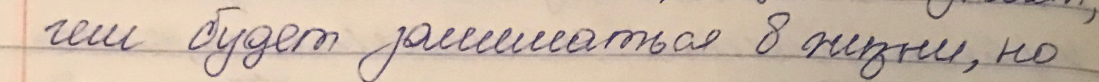

распознано: чем будет заниматься в жизни, но


In [4]:
IMG = '/mnt/DATA2/dorin/handwriting-recognition/data/image4.png'
img = Image.open(IMG).convert('RGB')
display(img)
print('распознано:', recognize(img))

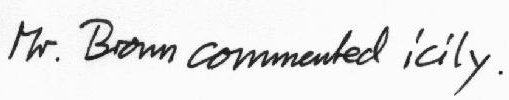

распознано: Mr. Brown commented icily .


In [5]:
import requests

url = "https://huggingface.co/datasets/Xenova/transformers.js-docs/resolve/main/handwriting.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
display(image)
print('распознано:', recognize(image))

## Примеры RU и EN (синтетика, gt vs предсказание)

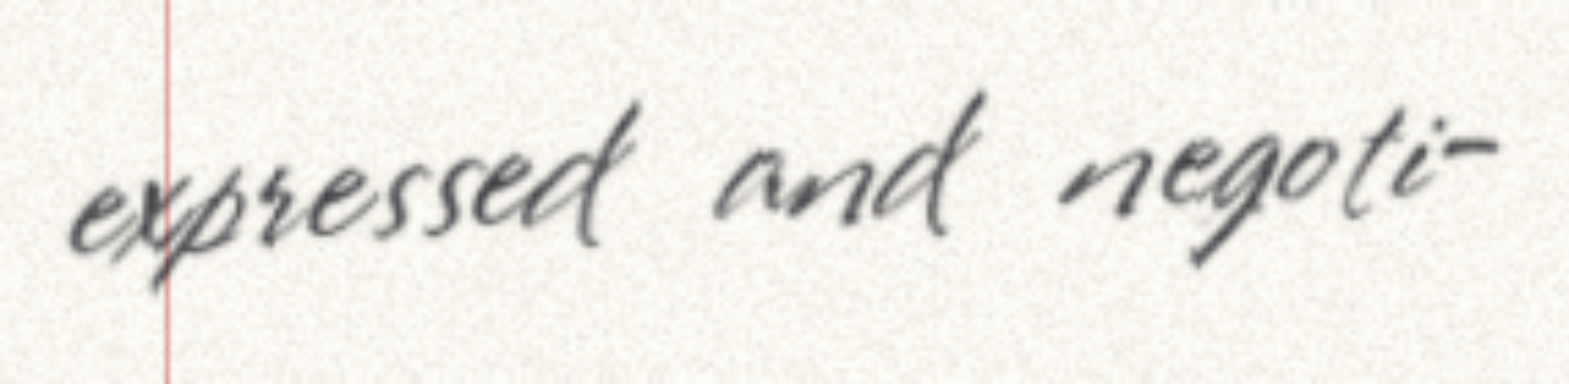

[en] gt:   expressed and negoti-
[en] pred: expressed and negoti-



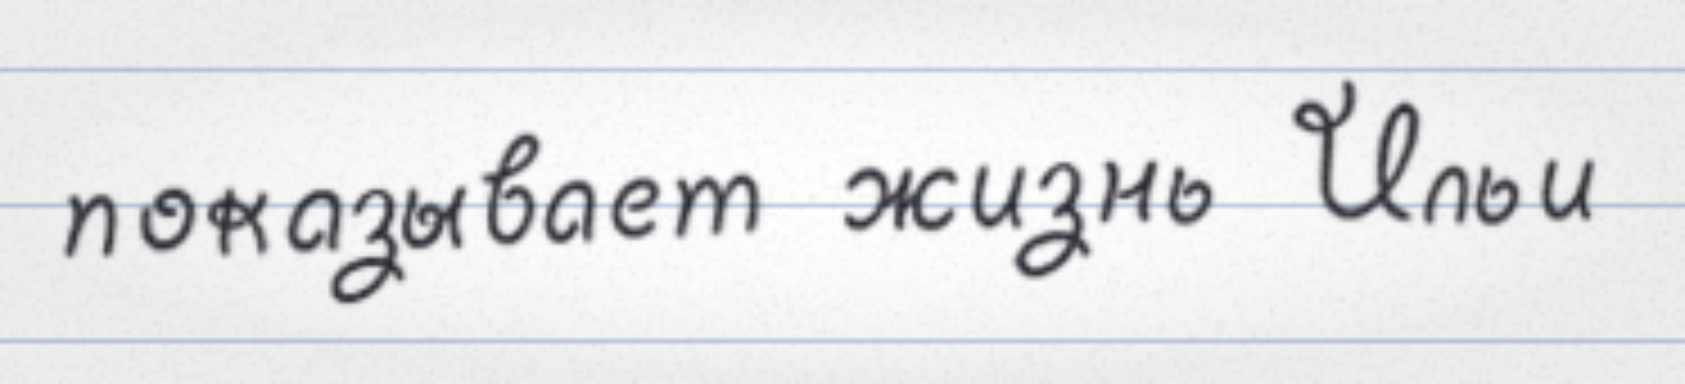

[ru] gt:   показывает жизнь Ильи
[ru] pred: показывает жизнь Ильи



In [4]:
import re
from src.synth import HandwrittenLineGenerator, make_generator

gen = HandwrittenLineGenerator.from_dirs(
    ru_text_dirs=["/mnt/DATA2/varlamova/HTR/trocr/data/texts/school"], en_text_dirs=["/mnt/DATA2/varlamova/HTR/trocr/data/texts/english"],
    ru_font_dirs=str(ROOT / 'assets' / 'fonts_ru'),
    en_font_dirs=str(ROOT / 'assets' / 'fonts_en'), p_ru=0.1, len_chars=(20, 50), p_hyphenate=0.5, curriculum=False)

examples, i = {}, 0
while len(examples) < 2 and i < 200:
    img, gt = gen.sample(make_generator(5, 0, i)); i += 1
    examples.setdefault('ru' if re.search('[а-яё]', gt, re.I) else 'en', (img, gt))

for lang, (img, gt) in examples.items():
    display(img)
    print(f'[{lang}] gt:   {gt}')
    print(f'[{lang}] pred: {recognize(img)}\n')

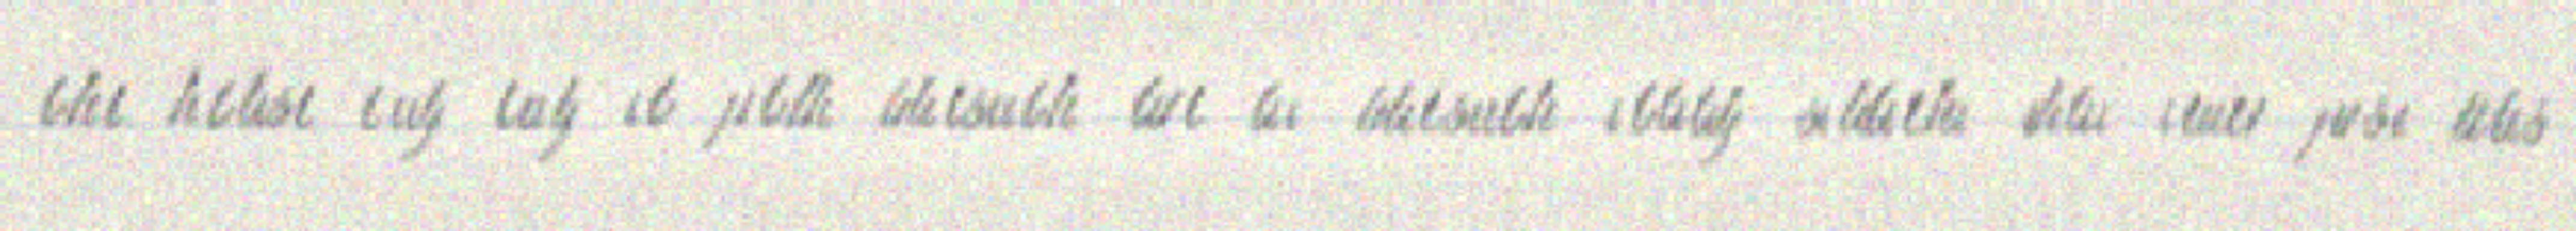

[en] gt:   one house city city to from question are at question today student that letter first was
[en] pred: one those try lay to from question are at presence today sidden that letter first was



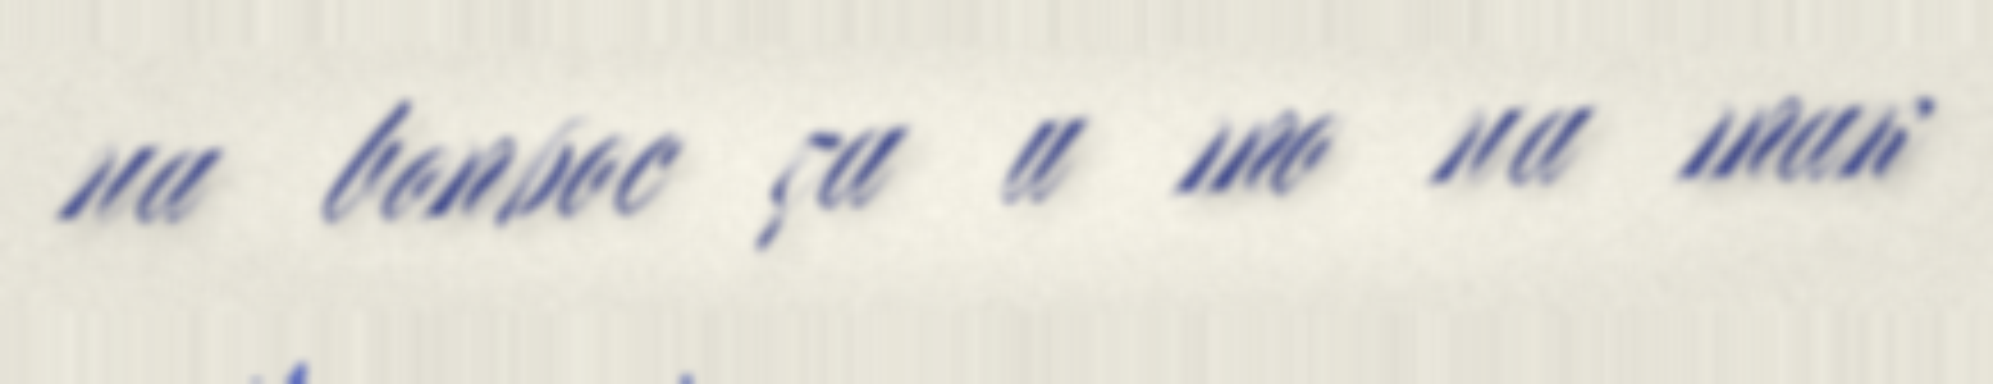

[ru] gt:   на вопрос за и то на так
[ru] pred: на вопрос за и то на тий



In [6]:
import sys
from pathlib import Path
from omegaconf import OmegaConf
import re

ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.synth import HandwrittenLineGenerator, make_generator

cfg = OmegaConf.load(ROOT / "configs" / "pretrain_stage2.yaml")

# те же параметры, что и во второй стадии обучения (run_pretrain.py)
gen = HandwrittenLineGenerator.from_dirs(
    ru_text_dirs=[], en_text_dirs=[],
    ru_font_dirs=str(ROOT / "assets" / "fonts_ru"),
    en_font_dirs=str(ROOT / "assets" / "fonts_en"),
    p_ru=cfg.data.p_ru, len_chars=tuple(cfg.data.len_chars), p_hyphenate=cfg.data.p_hyphenate,
    warmup_steps=cfg.synth.warmup_steps, seed=cfg.synth.seed,
    curriculum=bool(cfg.synth.get("curriculum", True)),
    synth_overrides=cfg.synth,                              # corpus/render/effects/neighbors/output из yaml
)

examples, i = {}, 0
while len(examples) < 2 and i < 200:
    img, gt = gen.sample(make_generator(4, 0, i)); i += 1
    examples.setdefault('ru' if re.search('[а-яё]', gt, re.I) else 'en', (img, gt))

for lang, (img, gt) in examples.items():
    display(img)
    print(f'[{lang}] gt:   {gt}')
    print(f'[{lang}] pred: {recognize(img)}\n')

## Как считаются метрики (CER / WER)

Каждые `eval_every` шагов на всём фиксированном val-наборе: для каждого батча
`model.generate` даёт предсказания, копим их вместе с эталонными строками, в конце
один раз считаем CER и WER через `jiwer`.

CER и WER основаны на расстоянии редактирования — сколько правок нужно, чтобы превратить
предсказание в эталон. Правки трёх видов:
- **S (замены)** — символ (или слово) распознан неправильно.
- **D (пропуски)** — символ есть в эталоне, но модель его не выдала.
- **I (вставки)** — модель выдала лишний символ, которого в эталоне нет.

CER считается на уровне символов, WER — на уровне слов:
- CER = сумма всех правок S + D + I, делённая на общее число символов в эталонах.
- WER = то же самое, но единица — слово.

**Усреднение micro, а не по строкам.** Все ошибки по всему val-набору складываются и
делятся на суммарную длину эталонов, а не усредняются по каждой строке отдельно. Поэтому
длинные строки влияют на метрику сильнее коротких.

Прочее:
- Считается в режиме `eval` без градиентов; val детерминированный, поэтому значения
  сравнимы между шагами.
- `loss` в `history.jsonl` — это loss одного батча на текущем шаге, он шумный и не
  усреднён. Ориентируйся на CER и WER.

Можно еще Word-level NES (normalized edit similarity, если ты про это) = это похожесть, а не ошибка: разная нормировка: WER делит на длину эталона, NES — на максимум из двух;

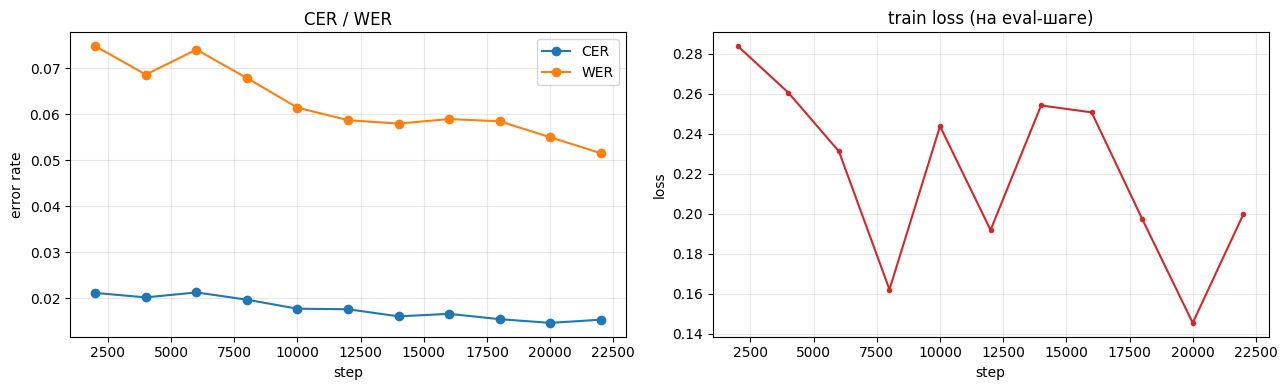

лучший CER 0.0146 (WER 0.0550) на шаге 20000


In [10]:
import json
import matplotlib.pyplot as plt

HISTORY = "../outputs/trocr_small_bi_pretrain_stage2/history.jsonl"

rows = [json.loads(l) for l in open(HISTORY, encoding="utf-8") if l.strip()]
rows.sort(key=lambda r: r["step"])          # на случай resume / перемешанного порядка
steps = [r["step"] for r in rows]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(steps, [r["cer"] for r in rows], marker="o", label="CER")
ax[0].plot(steps, [r["wer"] for r in rows], marker="o", label="WER")
ax[0].set_xlabel("step"); ax[0].set_ylabel("error rate"); ax[0].set_title("CER / WER")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(steps, [r.get("loss") for r in rows], color="tab:red", marker=".")
ax[1].set_xlabel("step"); ax[1].set_ylabel("loss"); ax[1].set_title("train loss (на eval-шаге)")
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

best = min(rows, key=lambda r: r["cer"])
print(f"лучший CER {best['cer']:.4f} (WER {best['wer']:.4f}) на шаге {best['step']}")

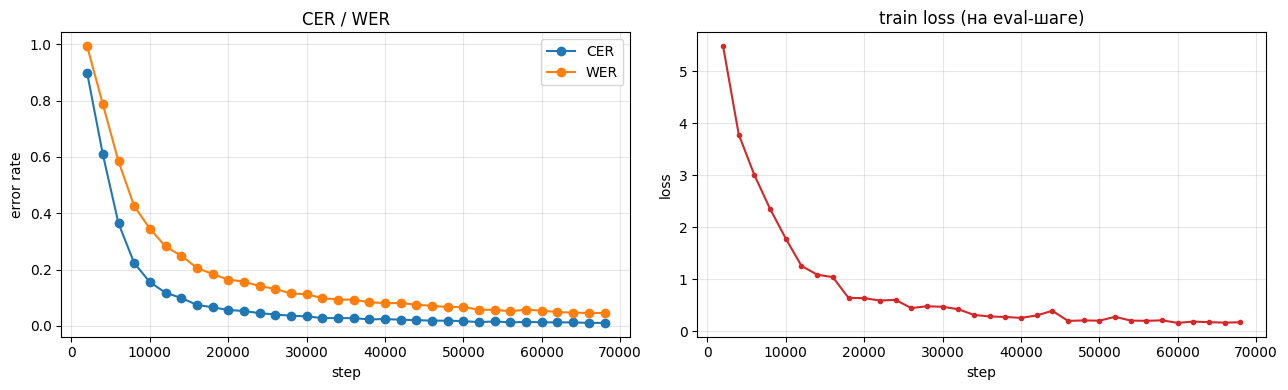

лучший CER 0.0108 (WER 0.0462) на шаге 66000


In [23]:
import json
import matplotlib.pyplot as plt

HISTORY = "../outputs/trocr_small_bi_pretrain/history.jsonl"

rows = [json.loads(l) for l in open(HISTORY, encoding="utf-8") if l.strip()]
rows.sort(key=lambda r: r["step"])          # на случай resume / перемешанного порядка
steps = [r["step"] for r in rows]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(steps, [r["cer"] for r in rows], marker="o", label="CER")
ax[0].plot(steps, [r["wer"] for r in rows], marker="o", label="WER")
ax[0].set_xlabel("step"); ax[0].set_ylabel("error rate"); ax[0].set_title("CER / WER")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(steps, [r.get("loss") for r in rows], color="tab:red", marker=".")
ax[1].set_xlabel("step"); ax[1].set_ylabel("loss"); ax[1].set_title("train loss (на eval-шаге)")
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

best = min(rows, key=lambda r: r["cer"])
print(f"лучший CER {best['cer']:.4f} (WER {best['wer']:.4f}) на шаге {best['step']}")

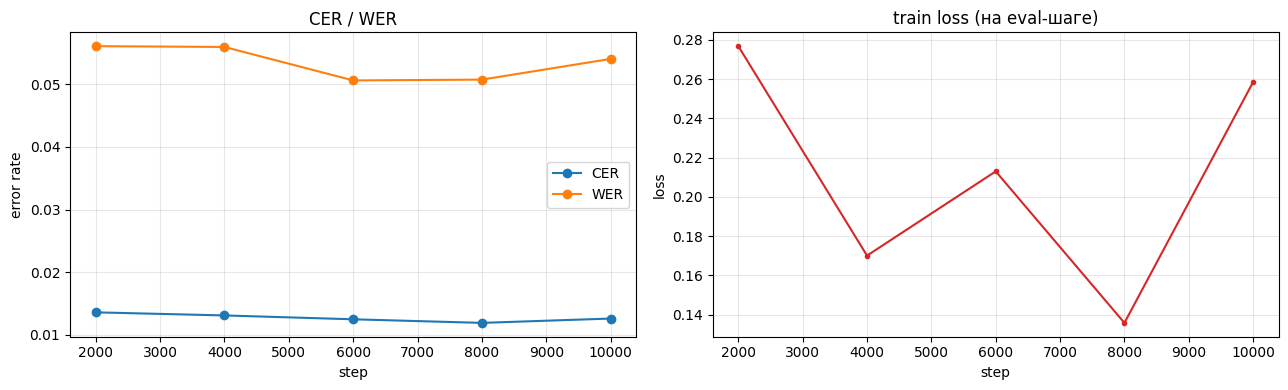

лучший CER 0.0119 (WER 0.0507) на шаге 8000


In [22]:
import json
import matplotlib.pyplot as plt

HISTORY = "../outputs/trocr_small_bi_pretrain_stage2/history.jsonl"

rows = [json.loads(l) for l in open(HISTORY, encoding="utf-8") if l.strip()]
rows.sort(key=lambda r: r["step"])          # на случай resume / перемешанного порядка
steps = [r["step"] for r in rows]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(steps, [r["cer"] for r in rows], marker="o", label="CER")
ax[0].plot(steps, [r["wer"] for r in rows], marker="o", label="WER")
ax[0].set_xlabel("step"); ax[0].set_ylabel("error rate"); ax[0].set_title("CER / WER")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(steps, [r.get("loss") for r in rows], color="tab:red", marker=".")
ax[1].set_xlabel("step"); ax[1].set_ylabel("loss"); ax[1].set_title("train loss (на eval-шаге)")
ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

best = min(rows, key=lambda r: r["cer"])
print(f"лучший CER {best['cer']:.4f} (WER {best['wer']:.4f}) на шаге {best['step']}")